In [1]:
import pandas as pd
import numpy as np
from termcolor import colored
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_style("darkgrid")

# Load correct dataset (536 games)
df_games = pd.read_csv('../data/games_preprocessed.csv')
df_games['processed_description'] = df_games['processed_description'].fillna('')
print(colored(f'Documents loaded: {len(df_games)}', 'green'))
df_games.head()

Documents loaded: 536


,app_id,title,genre,url,description,rating,ratings,reviews,desc_length,processed_description,processed_tokens,processed_length
0,ai.character.app,"Character AI: Chat, Talk, Text",Entretenimiento,https://play.google.com/store/apps/details?id=...,✨Character.AI no es solo otra aplicación de co...,1.362544,2253536.0,6382.0,611,character ai aplicación conversación ia patio ...,"['character', 'ai', 'aplicación', 'conversació...",305
1,air.com.bmapps.gossipgirlsdivasinhighschool,Gossip Girls Divas Highschool,Entretenimiento,https://play.google.com/store/apps/details?id=...,Estas tres chicas de secundaria quieren ser di...,3.558442,15228.0,30.0,378,chica secundaria querer diva real horario prog...,"['chica', 'secundaria', 'querer', 'diva', 'rea...",158
2,air.com.buffalo_studios.newflashbingo,Bingo Blitz™️: juegos de Bingo,Juegos de mesa,https://play.google.com/store/apps/details?id=...,Experimenta tu juego de bingo en línea como nu...,4.429238,1417570.0,2475.0,618,experimenta bingo línea adentrar aventura jueg...,"['experimenta', 'bingo', 'línea', 'adentrar', ...",275
3,air.com.flipline.papascheeseriatogo,Papa's Cheeseria To Go!,Estrategia,https://play.google.com/store/apps/details?id=...,-- SOBRE EL JUEGO --\r\n\r\n¡Papa's Cheeseria ...,4.739130,2293.0,2.0,650,juego cheeseria inaugurar inauguración actuaci...,"['juego', 'cheeseria', 'inaugurar', 'inaugurac...",312
4,air.com.flipline.papascluckeriatogo,Papa's Cluckeria To Go!,Estrategia,https://play.google.com/store/apps/details?id=...,-- SOBRE EL JUEGO --\r\n\r\n¡La Guerra de los ...,4.772728,2122.0,9.0,638,juego guerra sándwiches pollo comenzar papa lo...,"['juego', 'guerra', 'sándwiches', 'pollo', 'co...",324


In [2]:
texts = df_games['processed_description'].str.split().tolist()
print(colored(f'Avg tokens per document: {np.mean([len(t) for t in texts]):.1f}', 'blue'))
print(colored(f'Sample: {texts[0][:10]}', 'blue'))

Avg tokens per document: 166.3
Sample: ['character', 'ai', 'aplicación', 'conversación', 'ia', 'patio', 'recreo', 'infinito', 'imaginación', 'creatividad']


In [3]:
from gensim import corpora

In [4]:
dictionary = corpora.Dictionary(texts)
print("Original vocabulary size:", len(dictionary))

Original vocabulary size: 11598


In [5]:
# Filter vocabulary extremes:
# - no_below=2: remove words appearing in fewer than 2 documents (hapax legomena)
# - no_above=0.8: remove words appearing in more than 80% of documents (too generic)
# This reduces noise and vocabulary size from 10885 to 5113 terms
dictionary.filter_extremes(no_below=2, no_above=0.8)
print("Filtered vocabulary size:", len(dictionary))

Filtered vocabulary size: 5378


In [6]:
corpus_bow = [dictionary.doc2bow(text) for text in texts]
len(corpus_bow)

536

In [7]:
corpus_bow[0][:10]

[(0, 2),
 (1, 9),
 (2, 1),
 (3, 1),
 (4, 1),
 (5, 1),
 (6, 2),
 (7, 1),
 (8, 1),
 (9, 1)]

In [8]:
[(dictionary[id], count) for id, count in corpus_bow[0][:10]]

[('adaptar', 2),
 ('ai', 9),
 ('albergar', 1),
 ('alternativa', 1),
 ('ampliar', 1),
 ('apasionante', 1),
 ('aplicación', 2),
 ('aprender', 1),
 ('aprendizaje', 1),
 ('asistente', 1)]

In [9]:
from gensim import models

tfidf_model = models.TfidfModel(corpus_bow)
corpus_tfidf = tfidf_model[corpus_bow]

len(corpus_tfidf)

536

In [10]:
list(corpus_tfidf)[0][:10]

[(0, 0.040569998165998),
 (1, 0.30222702345941005),
 (2, 0.04013943740416657),
 (3, 0.03477401063506319),
 (4, 0.02437259722283496),
 (5, 0.036185302477319034),
 (6, 0.016807127493709606),
 (7, 0.017347493410325616),
 (8, 0.03163543717477225),
 (9, 0.029408583865959813)]

In [11]:
[(dictionary[id], score) for id, score in list(corpus_tfidf)[0][:10]]

[('adaptar', 0.040569998165998),
 ('ai', 0.30222702345941005),
 ('albergar', 0.04013943740416657),
 ('alternativa', 0.03477401063506319),
 ('ampliar', 0.02437259722283496),
 ('apasionante', 0.036185302477319034),
 ('aplicación', 0.016807127493709606),
 ('aprender', 0.017347493410325616),
 ('aprendizaje', 0.03163543717477225),
 ('asistente', 0.029408583865959813)]

In [12]:
num_docs = len(df_games)
vocab_size = len(dictionary)

print("Number of documents:", num_docs)
print("Vocabulary size after filtering:", vocab_size)

Number of documents: 536
Vocabulary size after filtering: 5378



## Bag of Words and TF-IDF Vectorization

In this notebook, the `processed_description` column is used to build classical text vector representations for each game.

First, a Gensim dictionary is created from the tokenized descriptions. Then, extreme terms are filtered using:
- `no_below=2`: removes words that appear in fewer than 2 documents
- `no_above=0.8`: removes words that appear in more than 80% of documents

After that:
- **Bag of Words (BoW)** represents each game as `(word_id, count)` pairs
- **TF-IDF** represents each game as `(word_id, weight)` pairs, where more important words get higher scores

In [13]:
import pickle

with open("../data/vectors_bow.pkl", "wb") as f:
    pickle.dump(corpus_bow, f)

with open("../data/vectors_tfidf.pkl", "wb") as f:
    pickle.dump(list(corpus_tfidf), f)

print("BoW and TF-IDF vectors saved successfully.")

BoW and TF-IDF vectors saved successfully.


In [14]:
import os

print(os.path.exists("../data/vectors_bow.pkl"))
print(os.path.exists("../data/vectors_tfidf.pkl"))

True
True


In [15]:
from collections import defaultdict

genre_docs = defaultdict(list)

for _, row in df_games.iterrows():
    genre_docs[row["genre"]].append(row["processed_description"].split())

print("Number of genres:", len(genre_docs))
print(list(genre_docs.keys())[:10])

Number of genres: 44
['Entretenimiento', 'Juegos de mesa', 'Estrategia', 'Acción', 'Casuales', 'Deportes', 'Aventura', 'Casino', 'Puzles', 'Arte y diseño']


In [16]:
from collections import Counter

genre_top_words = {}

for genre, docs in genre_docs.items():
    all_words = [word for doc in docs for word in doc]
    genre_top_words[genre] = Counter(all_words).most_common(10)

genre_top_words["Arcade"]

[('nivel', 55),
 ('juego', 29),
 ('cocina', 29),
 ('desafío', 27),
 ('mundo', 27),
 ('tiempo', 22),
 ('alto', 21),
 ('divertido', 21),
 ('amigo', 21),
 ('adictivo', 20)]

In [17]:
for genre in ["Arcade", "Acción", "Aventura", "Estrategia", "Puzles"]:
    print(f"\n{genre}:")
    print(genre_top_words[genre])


Arcade:
[('nivel', 55), ('juego', 29), ('cocina', 29), ('desafío', 27), ('mundo', 27), ('tiempo', 22), ('alto', 21), ('divertido', 21), ('amigo', 21), ('adictivo', 20)]

Acción:
[('batalla', 111), ('combate', 92), ('arma', 88), ('acción', 87), ('equipo', 83), ('mundo', 78), ('juego', 70), ('jugador', 68), ('habilidad', 67), ('enemigo', 60)]

Aventura:
[('aventura', 44), ('juego', 41), ('escape', 33), ('objeto', 29), ('mundo', 27), ('misterio', 26), ('oculto', 25), ('descubrir', 24), ('juegos', 24), ('resolver', 23)]

Estrategia:
[('cliente', 96), ('especial', 66), ('batalla', 56), ('estrategia', 50), ('ingrediente', 47), ('juego', 41), ('único', 41), ('él', 39), ('ganar', 38), ('jugar', 35)]

Puzles:
[('nivel', 103), ('bloque', 95), ('puzl', 84), ('rompecabeza', 81), ('juego', 80), ('color', 71), ('sudoku', 62), ('él', 61), ('jugar', 50), ('puzzle', 42)]


In [18]:
# Top words per genre as DataFrame - fix unequal lengths
max_len = max(len(v) for v in genre_top_words.values())
top_words_df = pd.DataFrame({
    genre: [word for word, count in genre_top_words[genre]] + [''] * (max_len - len(genre_top_words[genre]))
    for genre in genre_top_words
})
top_words_df.head(10)

,Entretenimiento,Juegos de mesa,Estrategia,Acción,Casuales,Deportes,Aventura,Casino,Puzles,Arte y diseño,...,Comunicación,Automoción,Casa y hogar,Medicina,Preguntas,Eventos,Aplicaciones de vídeo,Noticias y revistas,Cómics,Libros y obras de consulta
0,ia,ajedrez,cliente,batalla,jugar,equipo,aventura,casino,nivel,función,...,empleado,google,solicitud,aplicación,juego,evento,pantalla,noticia,manga,biblia
1,aplicación,bingo,especial,combate,nivel,jugador,juego,tragaperra,bloque,dibujo,...,whatsapp,aplicación,venta,médico,acertijo,jugador,grabar,aplicación,mangafire,viaje
2,lego,mahjong,batalla,arma,mundo,hockey,escape,vegas,puzl,crear,...,tiempo,android,línea,simplepractice,mental,presentar,video,calidad,descubrir,alpha
3,conversación,juego,estrategia,acción,juego,jugar,objeto,tragamonedas,rompecabeza,diseño,...,opción,acceder,,portal,prueba,aplicación,grabador,artículo,título,aplicación
4,personaje,juegos,ingrediente,equipo,disfrutar,partido,mundo,slots,juego,plan,...,messenger,auto,,cita,rompecabeza,oficial,captura,descubrir,explorar,nota
5,él,ficha,juego,mundo,amigo,mundo,misterio,juego,color,premium,...,foto,vehículo,,utilizar,cerebro,magic,smarters,smartnews,búsqueda,él
6,carta,jugar,único,juego,hole,juego,oculto,máquina,sudoku,utilizar,...,ia,necesitar,,client,adictivo,the,player,favorito,sencillo,contenido
7,divertido,mundo,él,jugador,aplicación,real,descubrir,slotomania,él,gratuito,...,sling,conectado,,atención,divertido,gathering,pro,mejor,favorito,personal
8,video,jugador,ganar,habilidad,divertido,liga,juegos,premio,jugar,paint,...,grupo,asistente,,seguro,jugar,dispositivo,reproducción,experto,filtro,video
9,contenido,amigo,jugar,enemigo,él,nba,resolver,buffalo,puzzle,aplicación,...,enviar,recibir,,sesión,disfrutar,móvil,capturar,editor,leer,reflexión


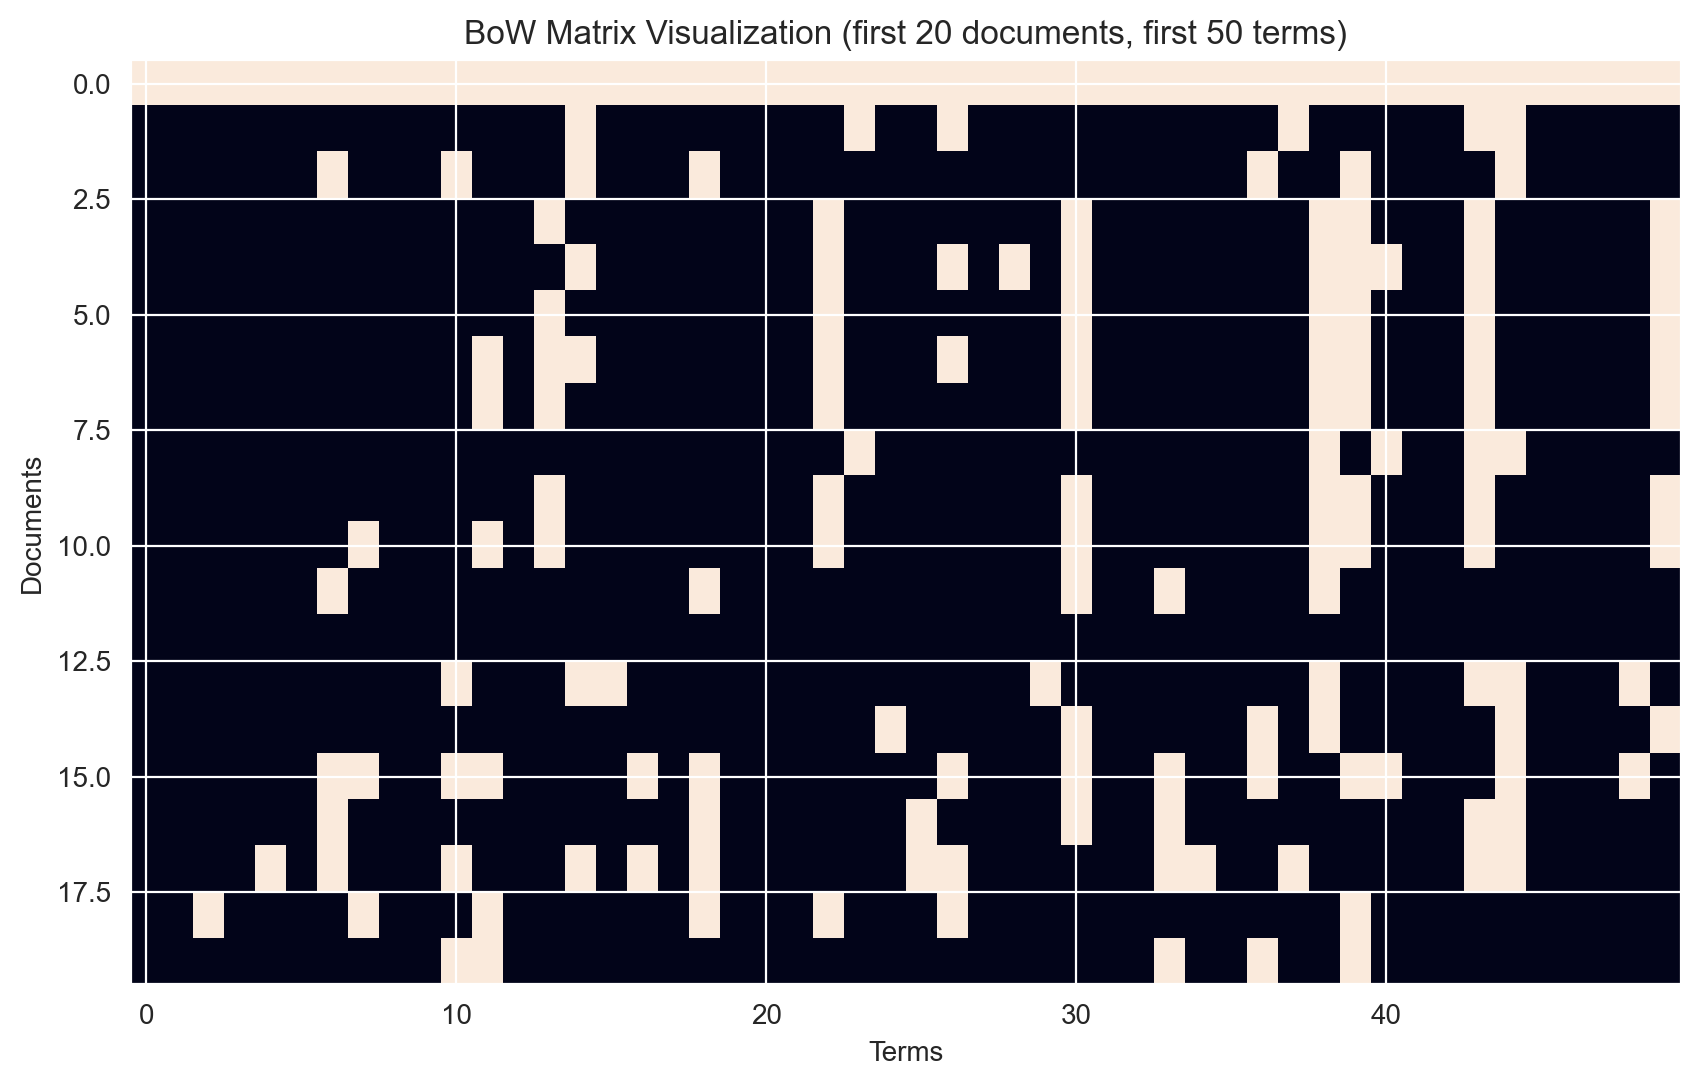

In [19]:
from gensim.matutils import corpus2csc
import matplotlib.pyplot as plt

bow_matrix = corpus2csc(corpus_bow).T.toarray()

plt.figure(figsize=(10, 6))
plt.imshow((bow_matrix[:20, :50] > 0).astype(int), aspect="auto")
plt.title("BoW Matrix Visualization (first 20 documents, first 50 terms)")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()

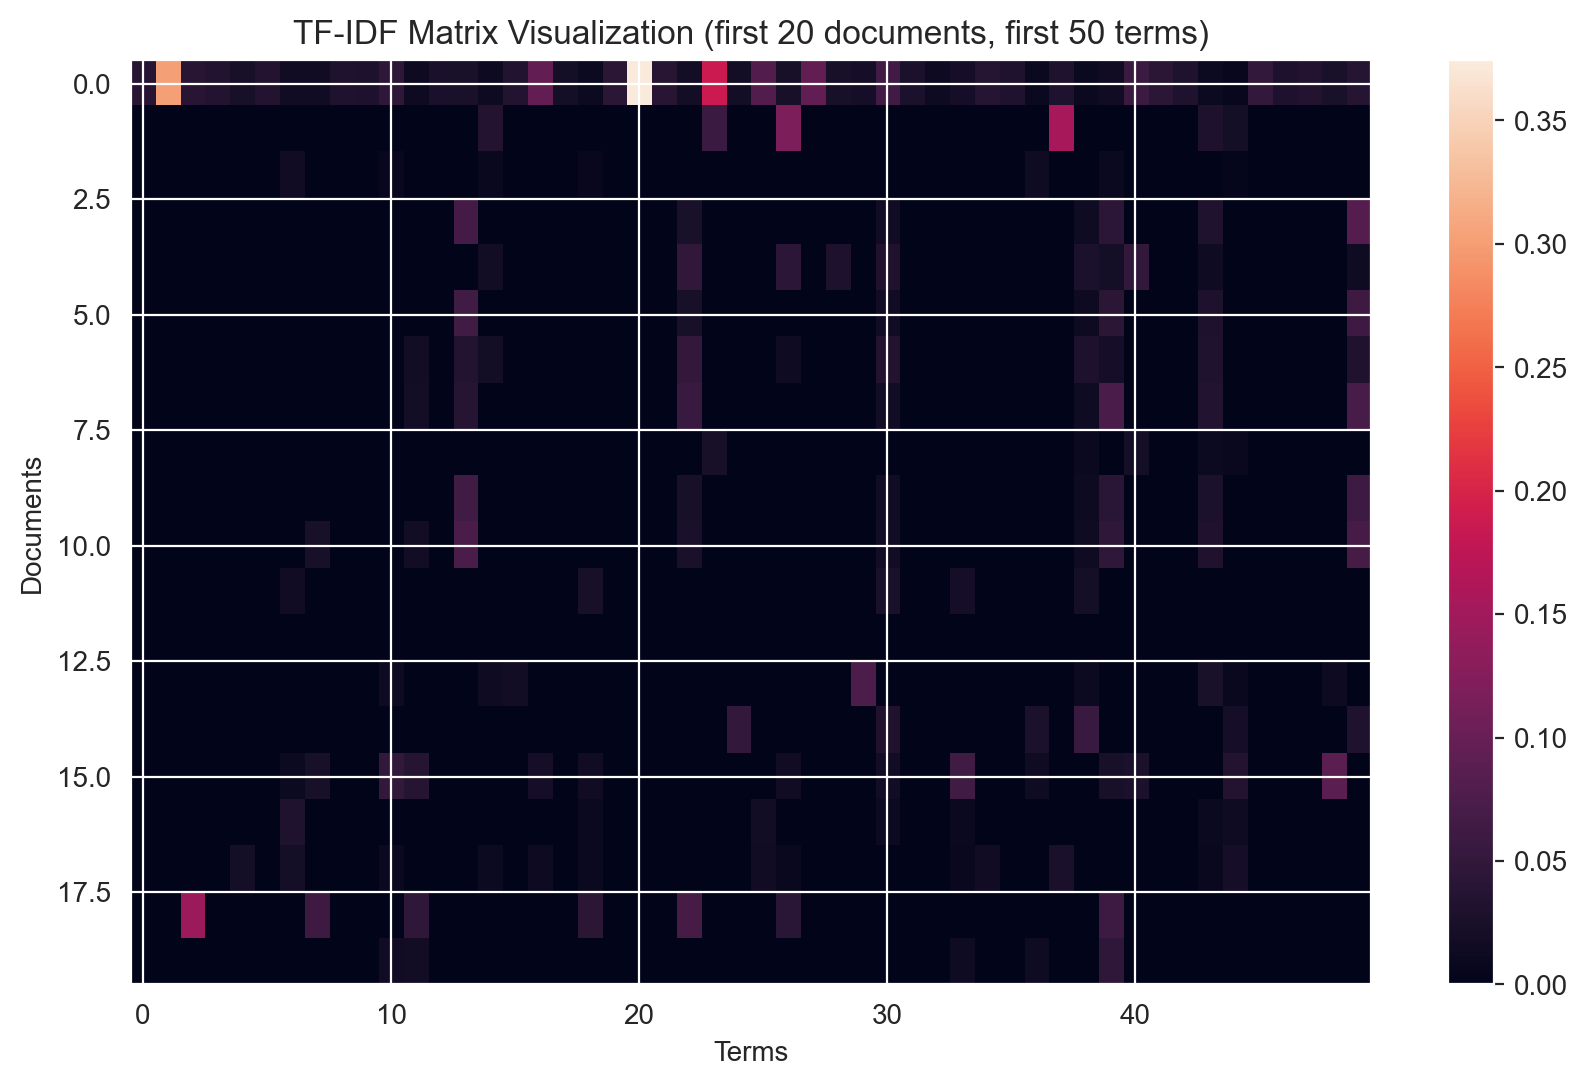

In [20]:
tfidf_matrix = corpus2csc(corpus_tfidf).T.toarray()

plt.figure(figsize=(10, 6))
plt.imshow(tfidf_matrix[:20, :50], aspect="auto")
plt.title("TF-IDF Matrix Visualization (first 20 documents, first 50 terms)")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.colorbar()
plt.show()

## Interpretation of Classical Vectorizations

The BoW matrix shows a sparse structure, where most word-document pairs are zero. This is expected in text data because each game description uses only a small subset of the total vocabulary.

The TF-IDF matrix is also sparse, but it highlights the relative importance of words instead of raw frequency. Terms with higher TF-IDF values are more informative for a specific game description and less common across the full dataset.

The top words by genre suggest that classical vectorization captures meaningful genre-specific vocabulary, although some noisy terms such as HTML remnants or generic game words are still present.